In [1]:
# Operate from the parent directory
# This allows us to import modules from the parent directory
import os
os.chdir("..")

import torch
from pose_encoder.advanced_pose_encoder import AdvancedPoseEncoder
from dataset.dataset import *
from utils.animation.skeleton import Skeleton
import utils.utils as utils
import matplotlib.pyplot as plt
import time

In [ ]:
dataset = GPUDataset(
    consolidated_file="dataset/genea2023_dataset/toy/main-agent/consolidated.npz",
    seq_length=2000, # For testing
    seed_length=0,
    batch_size=1,
    epoch_length=1,  # Set to 1 for testing purposes
    return_audio_frame_index=True,  # Set to True to return the audio frame index
)

pose_encoder_test = AdvancedPoseEncoder(
    pose_dim=345,
    component_definitions = {
        # Preserved (no encoding/decoding)
        'world_pos': {
            'bone_names': ['body_world'],
            'type': 'preserve',
            'use_position': True
        },
        'left_hand_rot': {
            'bone_name': 'b_l_wrist',
            'type': 'world_preserve_after_ik'
        },
        'right_hand_rot': {
            'bone_name': 'b_r_wrist',
            'type': 'world_preserve_after_ik'
        },
        'left_foot_rot': {
            'bone_name': 'b_l_foot',
            'type': 'world_preserve_after_ik'
        },
        'right_foot_rot': {
            'bone_name': 'b_r_foot',
            'type': 'world_preserve_after_ik'
        },
        # 'left_hand_rot': {
        #     'bone_names': ['b_l_wrist'],
        #     'type': 'preserve'
        # },
        # 'right_hand_rot': {
        #     'bone_names': ['b_r_wrist'],
        #     'type': 'preserve'
        # },
        # 'left_foot_rot': {
        #     'bone_names': ['b_l_foot'],
        #     'type': 'preserve'
        # },
        # 'right_foot_rot': {
        #     'bone_names': ['b_r_foot'],
        #     'type': 'preserve'
        # },        
        # Auto-encoded components - explicit bone lists
        'spine_shoulders_head': {
            'bone_names': [
                'b_root', 'b_spine0', 'b_spine1', 'b_spine2', 'b_spine3',
                'b_l_shoulder', 'b_r_shoulder', 'b_neck0', 'b_head'
            ],
            'type': 'preserve',
            'z_dim': 9
        },
        'left_hand_fingers': {
            'bone_names': [
                # Left thumb
                'b_l_thumb0', 'b_l_thumb1', 'b_l_thumb2', 'b_l_thumb3',
                # Left fingers  
                'b_l_index1', 'b_l_index2', 'b_l_index3',
                'b_l_middle1', 'b_l_middle2', 'b_l_middle3',
                'b_l_ring1', 'b_l_ring2', 'b_l_ring3',
                'b_l_pinky1', 'b_l_pinky2', 'b_l_pinky3'
            ],
            'type': 'preserve',
            'z_dim': 18
        },
        'right_hand_fingers': {
            'bone_names': [
                # Right thumb
                'b_r_thumb0', 'b_r_thumb1', 'b_r_thumb2', 'b_r_thumb3',
                # Right fingers
                'b_r_index1', 'b_r_index2', 'b_r_index3',
                'b_r_middle1', 'b_r_middle2', 'b_r_middle3',
                'b_r_ring1', 'b_r_ring2', 'b_r_ring3',
                'b_r_pinky1', 'b_r_pinky2', 'b_r_pinky3'
            ],
            'type': 'preserve',
            'z_dim': 18
        },
        # IK components - using skeleton's enhanced chain info
        'left_arm_ik': {
            'type': 'ik',
            'chain_joints': ['b_l_arm', 'b_l_forearm'],
            'end_effector': 'b_l_wrist',
            'z_dim': 4,  # 3 for target position + 1 swivel rotation
            'twist_joint': 'b_l_arm_twist',
            'chain_parent': 'b_l_shoulder',
            'bone1_forward_dir': [0.9993694424629211, -0.023177823051810265, -0.026897454634308815],
            'bone1_up_dir': [-0.02316943369805813, -0.9997313618659973, 0.0006235920009203255],
            'bone2_forward_dir': [0.9993695020675659, -0.02317732758820057, -0.026897458359599113],
            'bone2_up_dir': [-0.023168936371803284, -0.9997313618659973, 0.0006235786713659763],
        },
        'right_arm_ik': {
            'type': 'ik',
            'chain_joints': ['b_r_arm', 'b_r_forearm'],
            'end_effector': 'b_r_wrist',
            'z_dim': 4,
            'twist_joint': 'b_r_arm_twist',
            'chain_parent': 'b_r_shoulder',
            'bone1_forward_dir': [-0.9992618560791016, -0.028031472116708755, -0.026267891749739647],
            'bone1_up_dir': [0.02802179381251335, -0.9996070861816406, 0.0007366171339526772],
            'bone2_forward_dir': [-0.9992617964744568, -0.028031865134835243, -0.02626790478825569],
            'bone2_up_dir': [0.02802218683063984, -0.9996070265769958, 0.0007366279023699462],
        },
        'left_leg_ik': {
            'type': 'ik',
            'chain_joints': ['b_l_upleg', 'b_l_leg'],
            'end_effector': 'b_l_foot',
            'z_dim': 4,
            'chain_parent': 'b_root',
            'bone1_forward_dir': [0.0, -0.9999752044677734, 0.007038275245577097],
            'bone1_up_dir': [0.0, 0.007038275711238384, 0.9999752640724182],
            'bone2_forward_dir': [0.0, -0.996783435344696, -0.0801420658826828],
            'bone2_up_dir': [0.0, 0.0801420658826828, -0.996783435344696],
        },
        'right_leg_ik': {
            'type': 'ik',
            'chain_joints': ['b_r_upleg', 'b_r_leg'],
            'end_effector': 'b_r_foot',
            'z_dim': 4,
            'chain_parent': 'b_root',
            'bone1_forward_dir': [0.0, -0.9999904632568359, 0.004357356112450361],
            'bone1_up_dir': [0.0, 0.0043573565781116486, 0.9999905228614807],
            'bone2_forward_dir': [0.0, -0.996783435344696, -0.0801420733332634],
            'bone2_up_dir': [0.0, 0.0801420733332634, -0.996783435344696],
        }
    },
    skeleton = dataset.skeleton,
    device = utils.get_device()
)

Initializing GPU-resident dataset on cuda
Loading data from dataset/genea2023_dataset/toy/main-agent/consolidated.npz directly to GPU...
Data loaded to GPU. Gesture shape: torch.Size([49628, 345]), Audio shape: torch.Size([49628, 37])
Found 28416 valid starting points for windows
Dataset initialization complete!

Unhandled bones that will use identity rotation:
  b_r_arm_twist: indices 57-62
  b_r_wrist_twist: indices 69-74
  b_l_arm_twist: indices 189-194
  b_l_wrist_twist: indices 201-206

=== Pose Encoder Component Information ===

world_pos (preserve):
  Indices: [0, 1, 2]
  Dimensions: 3

left_hand_rot (preserve):
  Indices: [207, 208, 209, 210, 211, 212]
  Dimensions: 6

right_hand_rot (preserve):
  Indices: [75, 76, 77, 78, 79, 80]
  Dimensions: 6

left_foot_rot (preserve):
  Indices: [339, 340, 341, 342, 343, 344]
  Dimensions: 6

right_foot_rot (preserve):
  Indices: [321, 322, 323, 324, 325, 326]
  Dimensions: 6

spine_shoulders_head (encode):
  Input dimensions: 54
  Latent 

In [3]:
# Import the viewer
import utils.animation.visualisation.new.animation_visualisation as animation_visualisation
animation_visualisation.init_visualization()
time.sleep(1)  # Wait for the visualization to initialize
animation_visualisation.send_character("ground_truth", (0.0,0.0,0.0), 0, "red")

Viewer URL: http://localhost:8000/utils/animation/visualisation/new/animation_viewer2.html?wsport=8700


TWIST ROTATION DETECTED
rot1: torch.Size([1, 3, 3]), twist_rot: torch.Size([1, 3, 3])
combined_rot1: torch.Size([1, 3, 3])
TWIST ROTATION DETECTED
rot1: torch.Size([1, 3, 3]), twist_rot: torch.Size([1, 3, 3])
combined_rot1: torch.Size([1, 3, 3])


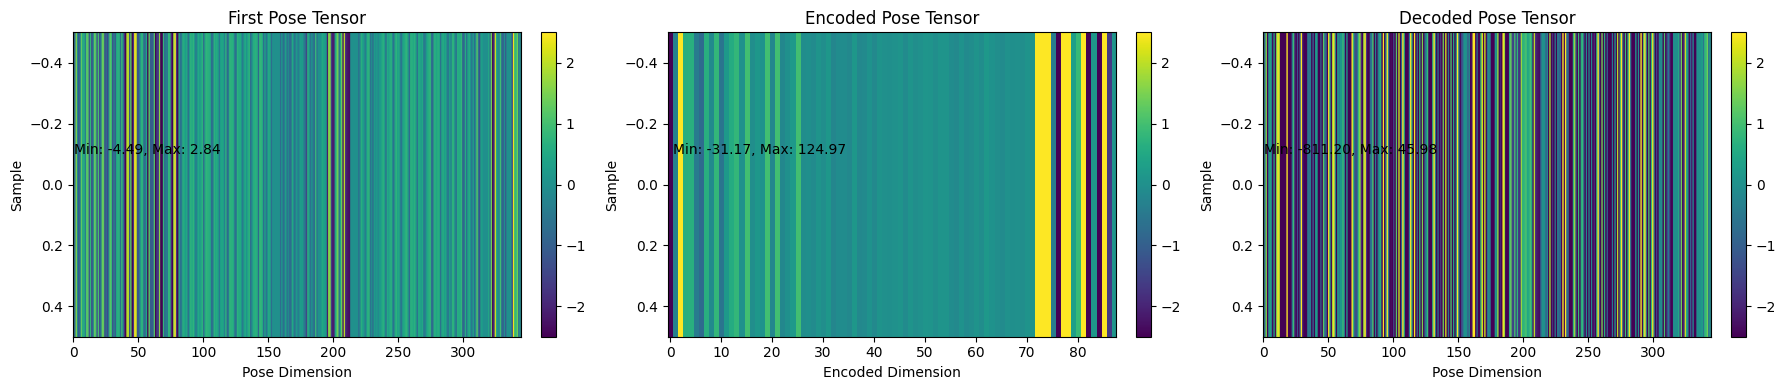

In [11]:
dataset.reshuffle()

with torch.no_grad():
    # Get a sample from the dataset
    # gesture_sequence, seed_gesture, audio_features, main_agent_id_one_hot, full_audio_features, start_frame, file = next(iter(dataset))
    gesture_sequence, seed_gesture, audio_features, main_agent_id_one_hot, start_frames = next(iter(dataset))

    skeleton: Skeleton = dataset.skeleton

    # gesture_sequence = skeleton.denormalize_poses(gesture_sequence)

    # Extract the first pose from the sequence
    first_pose = gesture_sequence.squeeze(0)[0].unsqueeze(0).float()

    # Encode the first pose
    encoded_pose = pose_encoder_test.encode(first_pose)

    # Decode the encoded pose back to the original pose space
    decoded_pose = pose_encoder_test.decode(encoded_pose)

    show = True

    if show:
        fig, axs = plt.subplots(1, 3, figsize=(18, 4))

        # First pose
        im0 = axs[0].imshow(first_pose.cpu().numpy().reshape(1, -1), aspect='auto', cmap='viridis', vmin=-2.5, vmax=2.5)
        axs[0].set_title("First Pose Tensor")
        axs[0].set_xlabel("Pose Dimension")
        axs[0].set_ylabel("Sample")
        # write the min and max values of the pose tensor
        axs[0].text(0.5, -0.1, f"Min: {first_pose.min().item():.2f}, Max: {first_pose.max().item():.2f}")
        plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

        # Encoded pose
        im1 = axs[1].imshow(encoded_pose.cpu().numpy().reshape(1, -1), aspect='auto', cmap='viridis', vmin=-2.5, vmax=2.5)
        axs[1].set_title("Encoded Pose Tensor")
        axs[1].set_xlabel("Encoded Dimension")
        axs[1].set_ylabel("Sample")
        # write the min and max values of the encoded pose tensor
        axs[1].text(0.5, -0.1, f"Min: {encoded_pose.min().item():.2f}, Max: {encoded_pose.max().item():.2f}")
        plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

        # Decoded pose
        im2 = axs[2].imshow(decoded_pose.cpu().numpy().reshape(1, -1), aspect='auto', cmap='viridis', vmin=-2.5, vmax=2.5)
        axs[2].set_title("Decoded Pose Tensor")
        axs[2].set_xlabel("Pose Dimension")

        axs[2].set_ylabel("Sample")
        # write the min and max values of the decoded pose tensor
        axs[2].text(0.5, -0.1, f"Min: {decoded_pose.min().item():.2f}, Max: {decoded_pose.max().item():.2f}")
        plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()

    # print(.shape)
    animation_visualisation.send_pose(skeleton.denormalize_poses(first_pose).squeeze().cpu(), dataset.skeleton, "ground_truth")
    animation_visualisation.send_pose(skeleton.denormalize_poses(decoded_pose).squeeze().cpu(), dataset.skeleton)

    # The last 4x4 rows of the encoded pose are the IK target positions + swivel rotations (3 for position + 1 for swivel)
    # Extract the IK target positions from the encoded pose
    ik_target_positions_and_swivel = encoded_pose[0, -4*4:].cpu().numpy()

    # remove the swivel rotation (the last 4th value in each 4D block)
    ik_target_positions = ik_target_positions_and_swivel.reshape(-1, 4)[:, :3]  # Reshape to (4, 3) and remove swivel

    # Send IK target positions to the visualization
    # construct a tensor of shape (4, 3) from the ik_target_positions
    ik_target_tensor = torch.tensor(ik_target_positions).reshape(4, 3)

    # print("IK Target Positions (without swivel):")
    # print(ik_target_tensor)

    # animation_visualisation.send_debug_positions(torch.cat([ik_reconstructed_elbow_pos, ik_reconstructed_target_pos], dim=0))

    # I want to calculate the world position of the joints.
    world_positions = skeleton.calculate_world_positions(first_pose.unsqueeze(0))

    # reshape to (batch_size, num_frames, num_joints, 3)
    world_positions = world_positions.reshape(len(skeleton.target_joints), 3)

    # animation_visualisation.send_debug_positions(world_positions)

In [5]:
print(first_pose.squeeze().cpu().shape)
rest_pose = utils.get_rest_pose(58, device=utils.get_device())
print(rest_pose.cpu().shape)
animation_visualisation.send_pose(rest_pose.cpu(), skeleton=dataset.skeleton)

encoded_pose = pose_encoder_test.encode(rest_pose.unsqueeze(0))

# The last 4x4 rows of the encoded pose are the IK target positions + swivel rotations (3 for position + 1 for swivel)
# Extract the IK target positions from the encoded pose
ik_target_positions_and_swivel = encoded_pose[0, -4*4:].detach().cpu().numpy()

# remove the swivel rotation (the last 4th value in each 4D block)
ik_target_positions = ik_target_positions_and_swivel.reshape(-1, 4)[:, :3]  # Reshape to (4, 3) and remove swivel

# Send IK target positions to the visualization
# construct a tensor of shape (4, 3) from the ik_target_positions
ik_target_tensor = torch.tensor(ik_target_positions).reshape(4, 3)

print("IK Target Positions (without swivel):")
print(ik_target_tensor)

# animation_visualisation.send_debug_positions(ik_target_tensor)

def get_exact_bone_directions(skeleton, rest_pose, joint_name1, joint_name2):
    """Extract exact bone direction from rest pose."""
    # Calculate world positions in rest pose
    world_pos = skeleton.calculate_world_positions(rest_pose.unsqueeze(0))
    world_pos = world_pos.reshape(-1, len(skeleton.target_joints), 3)
    
    # Get joint indices
    idx1 = skeleton.target_joints.index(joint_name1)
    idx2 = skeleton.target_joints.index(joint_name2)
    
    # Get positions
    pos1 = world_pos[0, idx1].cpu()
    pos2 = world_pos[0, idx2].cpu()
    
    # Calculate exact normalized bone direction vector
    forward_dir = pos2 - pos1
    forward_dir = forward_dir / torch.norm(forward_dir)
    
    # Find perpendicular up direction (can use skeleton's up vector as reference)
    world_up = torch.tensor([0.0, 1.0, 0.0])
    right_dir = torch.linalg.cross(forward_dir, world_up)
    
    # Handle case where forward is aligned with world up
    if torch.norm(right_dir) < 1e-6:
        world_forward = torch.tensor([0.0, 0.0, 1.0])
        right_dir = torch.linalg.cross(world_forward, forward_dir)
    
    right_dir = right_dir / torch.norm(right_dir)
    up_dir = torch.linalg.cross(right_dir, forward_dir)
    up_dir = up_dir / torch.norm(up_dir)
    
    return {
        "bone": f"{joint_name1}->{joint_name2}",
        "forward_dir": forward_dir.tolist(),
        "up_dir": up_dir.tolist()
    }

print ("=== Exact Bone Directions ===")
print(get_exact_bone_directions(skeleton, rest_pose, 'b_l_upleg', 'b_l_leg'))
print(get_exact_bone_directions(skeleton, rest_pose, 'b_l_leg', 'b_l_foot'))
print ("----"*10)
print(get_exact_bone_directions(skeleton, rest_pose, 'b_r_upleg', 'b_r_leg'))
print(get_exact_bone_directions(skeleton, rest_pose, 'b_r_leg', 'b_r_foot'))
print ("===="*10)
print(get_exact_bone_directions(skeleton, rest_pose, 'b_l_arm', 'b_l_forearm'))
print(get_exact_bone_directions(skeleton, rest_pose, 'b_l_forearm', 'b_l_wrist_twist'))
print ("----"*10)
print(get_exact_bone_directions(skeleton, rest_pose, 'b_r_arm', 'b_r_forearm'))
print(get_exact_bone_directions(skeleton, rest_pose, 'b_r_forearm', 'b_r_wrist_twist'))

torch.Size([345])
torch.Size([345])
TWIST ROTATION DETECTED
rot1: torch.Size([1, 3, 3]), twist_rot: torch.Size([1, 3, 3])
combined_rot1: torch.Size([1, 3, 3])
TWIST ROTATION DETECTED
rot1: torch.Size([1, 3, 3]), twist_rot: torch.Size([1, 3, 3])
combined_rot1: torch.Size([1, 3, 3])
IK Target Positions (without swivel):
tensor([[ 32.8200,  87.9052,   8.3809],
        [-32.2469,  89.2805,  10.3678],
        [ 12.5830,   7.8768,  -1.0388],
        [-11.3910,   8.2300,  -2.1266]])
=== Exact Bone Directions ===
{'bone': 'b_l_upleg->b_l_leg', 'forward_dir': [0.0, -0.9999752044677734, 0.007038275245577097], 'up_dir': [0.0, 0.007038275711238384, 0.9999752640724182]}
{'bone': 'b_l_leg->b_l_foot', 'forward_dir': [0.0, -0.996783435344696, -0.0801420658826828], 'up_dir': [0.0, 0.0801420658826828, -0.996783435344696]}
----------------------------------------
{'bone': 'b_r_upleg->b_r_leg', 'forward_dir': [0.0, -0.9999904632568359, 0.004357356112450361], 'up_dir': [0.0, 0.0043573565781116486, 0.999990